[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter2_lecture_notebook.ipynb)

# Statistics of Financial Markets — Chapter 2: Classical distributions and stylised facts

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The Normal and lognormal distributions, the central limit theorem (CLT) and the Normal approximation.
- Moments (skewness, excess kurtosis), the Jarque-Bera test, QQ plots and the Student-t distribution.
- Six stylised facts of returns (Cont, 2001) on the S&P 500, DAX, BET, Bitcoin and four BVB stocks, 2010-2026.
- Textbook: Franke, Härdle and Hafner (2019), *Statistics of Financial Markets*, 5th ed., Sec. 3.3 and 11.2.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_2'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/SFM - Statistica pietelor financiare/2026/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Definitions used in the whole notebook

- `returns(name)`: daily log returns in %, from 2010 (or from the first day of the series).
- Sample skewness $S = m_3/m_2^{3/2}$, excess kurtosis $K = m_4/m_2^2 - 3$, Jarque-Bera $JB = \frac{n}{6}(S^2 + K^2/4)$.
- Student-t fit by maximum likelihood (`scipy.stats.t.fit`), AIC $= 2k - 2\ell$.
- $k$-sigma days: $|r_t - \bar r| > k s$; ACF $\hat\rho(h)$, Ljung-Box $Q(m)$, leverage $L(k) = \mathrm{Corr}(r_t, |r_{t+k}|)$; non-overlapping $h$-day returns.

In [5]:
START = '2010-01-01'
ASSETS = ['sp500', 'dax', 'bet', 'btc', 'snp', 'brd', 'snn', 'sng']
INDICES = ['sp500', 'dax', 'bet', 'btc']
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'btc': '#B5853F', 'snp': '#8E44AD', 'brd': '#DC3545', 'snn': '#2E7D32', 'sng': '#E67E22', 'tlv': '#2E7D32'}
PAL = {'blue': '#1A3A6E', 'red': '#CD0000', 'green': '#2E7D32', 'amber': '#B5853F', 'purple': '#8E44AD', 'teal': '#17A2B8', 'orange': '#E67E22'}
SHORT = {'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET', 'btc': 'Bitcoin', 'snp': 'SNP', 'brd': 'BRD', 'snn': 'SNN', 'sng': 'SNG', 'tlv': 'TLV'}
HORIZONS = [1, 2, 5, 10, 21, 63]


def returns(name, start=START, end=None):
    """Daily log returns in %, from `start` or from the first day of the series if that is later."""
    s0 = max(start, SERIES[name][4])
    return log_returns(name, s0) if end is None else log_returns(name, s0, end)


def moments(r):
    """Sample moments of returns: mean, standard deviation, skewness, excess kurtosis (population formulas, as in
    the Jarque-Bera test), their standard errors under the Normal distribution, extremes and the 1%/99% quantiles."""
    r = pd.Series(r).dropna()
    n = len(r)
    s, k = stats.skew(r), stats.kurtosis(r)                  # kurtosis(): excess kurtosis (Normal = 0)
    jb = n / 6 * (s ** 2 + k ** 2 / 4)
    out = {'n': n, 'mean': r.mean(), 'sd': r.std(), 'skew': s, 'exkurt': k, 'kurt': k + 3,
           'se_skew': np.sqrt(6 / n), 'se_kurt': np.sqrt(24 / n), 'jb': jb, 'jb_p': stats.chi2.sf(jb, 2),
           'min': r.min(), 'max': r.max(), 'q01': r.quantile(0.01), 'q99': r.quantile(0.99)}
    if isinstance(r.index, pd.DatetimeIndex):
        out.update(min_date=r.idxmin().date().isoformat(), max_date=r.idxmax().date().isoformat(),
                   first=r.index[0].date().isoformat(), last=r.index[-1].date().isoformat())
    return out


def t_fit(r):
    """Maximum likelihood fit of a Student-t with location and scale; log-likelihood and AIC vs the Normal."""
    r = np.asarray(pd.Series(r).dropna())
    nu, loc, scale = stats.t.fit(r)
    ll_t = stats.t.logpdf(r, nu, loc, scale).sum()
    ll_n = stats.norm.logpdf(r, r.mean(), r.std(ddof=0)).sum()
    return {'nu': nu, 'loc': loc, 'scale': scale, 'll_t': ll_t, 'll_n': ll_n,
            'aic_t': 2 * 3 - 2 * ll_t, 'aic_n': 2 * 2 - 2 * ll_n,
            'sd_t': scale * np.sqrt(nu / (nu - 2)) if nu > 2 else np.inf}


def sigma_days(r, ks=(3, 4, 5, 6)):
    """k-sigma days: observed number of days with |r - mean| > k sd, the number expected under the Normal
    distribution, and the Poisson probability of seeing at least as many under the Normal distribution."""
    r = pd.Series(r).dropna()
    z = (r - r.mean()) / r.std()
    out = {}
    for k in ks:
        p = 2 * stats.norm.sf(k)
        obs = int((z.abs() > k).sum())
        exp = len(r) * p
        out[k] = {'obs': obs, 'exp': exp, 'ratio': obs / exp, 'p_normal': p, 'every_normal': 1 / p,
                  'every_obs': len(r) / obs if obs else np.inf, 'poisson_p': stats.poisson.sf(obs - 1, exp),
                  'down': int((z < -k).sum()), 'up': int((z > k).sum())}
    return out


def normal_tail_table(ks=(1, 2, 3, 4, 5, 6), days_per_year=252):
    """Two-sided tail probability P(|Z| > k) of the standard Normal distribution and the waiting time it implies."""
    return {k: {'p': 2 * stats.norm.sf(k), 'every_days': 1 / (2 * stats.norm.sf(k)),
                'every_years': 1 / (2 * stats.norm.sf(k)) / days_per_year} for k in ks}


def acf(x, nlags=50):
    """Sample autocorrelation function rho(1), ..., rho(nlags)."""
    x = np.asarray(x, dtype=float) - np.mean(x)
    d = np.sum(x * x)
    return np.array([np.sum(x[h:] * x[:-h]) / d for h in range(1, nlags + 1)])


def ljung_box(x, m=10):
    """Ljung-Box statistic Q(m) = n(n+2) sum_{h<=m} rho(h)^2 / (n-h) and its chi-square(m) p-value."""
    n = len(x)
    rho = acf(x, m)
    q = n * (n + 2) * np.sum(rho ** 2 / (n - np.arange(1, m + 1)))
    return {'Q': q, 'p': stats.chi2.sf(q, m), 'm': m}


def leverage(r, lags=20):
    """Leverage correlation L(k) = corr(r_t, |r_{t+k}|), k = 1..lags: a negative value means that falls are
    followed by higher volatility than rises."""
    r = pd.Series(r).dropna()
    a = r.abs()
    return np.array([np.corrcoef(r.iloc[:-k], a.iloc[k:])[0, 1] for k in range(1, lags + 1)])


def aggregate(r, h):
    """Non-overlapping h-period log returns (sums of h consecutive daily log returns)."""
    r = pd.Series(r).dropna()
    m = len(r) // h
    return pd.Series(r.values[:m * h].reshape(m, h).sum(axis=1))


def qq_points(r, dist='norm', params=None):
    """Theoretical and empirical quantiles for a QQ plot (plotting positions (i - 0.5)/n); standardised data
    against N(0,1), or raw data against a fitted t (params = (nu, loc, scale))."""
    r = np.sort(np.asarray(pd.Series(r).dropna()))
    n = len(r)
    u = (np.arange(1, n + 1) - 0.5) / n
    if dist == 'norm':
        return stats.norm.ppf(u), (r - r.mean()) / r.std()
    nu, loc, scale = params
    return stats.t.ppf(u, nu, loc, scale), r

## 1. The Normal distribution

- The 68-95-99.7 rule and the two-sided tail probabilities $P(|Z| > k)$.
- Under the Normal distribution a 4-sigma day happens once in about 63 years of trading.

In [6]:
def fig_normal_pdf(save=True):
    """Standard Normal density with the areas within 1, 2 and 3 standard deviations."""
    x = np.linspace(-4.2, 4.2, 600)
    fig, ax = plt.subplots(figsize=(9, 3.9))
    ax.plot(x, stats.norm.pdf(x), color=PAL['blue'], lw=2, label='Standard Normal density')
    for k, c, a in [(3, PAL['teal'], 0.18), (2, PAL['green'], 0.25), (1, PAL['blue'], 0.30)]:
        xx = x[np.abs(x) <= k]
        p = 1 - 2 * stats.norm.sf(k)
        ax.fill_between(xx, stats.norm.pdf(xx), color=c, alpha=a, label=f'within {k} sd: {100 * p:.2f}%')
    ax.set_xlabel('z = (x - mu) / sigma')
    ax.set_ylabel('Density')
    st.legend_outside_bottom(ax, ncol=4, y=-0.17)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch2_normal_pdf')
    return normal_tail_table()

,p,every_days,every_years
1,3.173105e-01,3.151487e+00,1.250590e-02
2,4.550026e-02,2.197789e+01,8.721387e-02
3,2.699796e-03,3.703983e+02,1.469835e+00
4,6.334248e-05,1.578719e+04,6.264759e+01
5,5.733031e-07,1.744278e+06,6.921738e+03
6,1.973175e-09,5.067973e+08,2.011101e+06


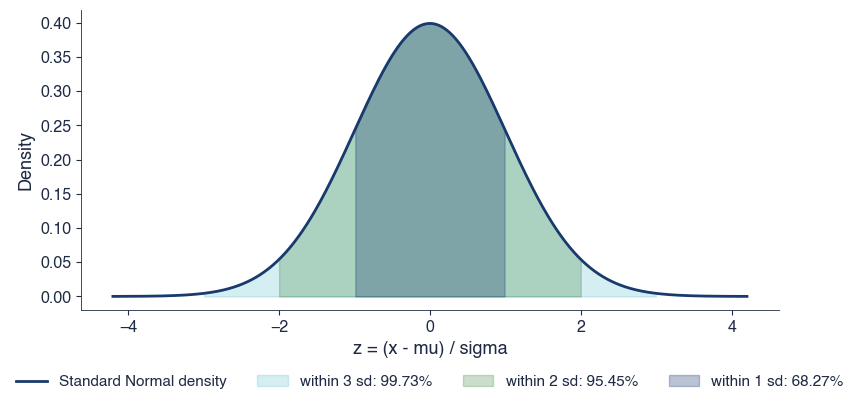

In [7]:
pd.DataFrame(fig_normal_pdf(save=False)).T

In [8]:
def loss_days(names=('sp500', 'bet', 'btc'), thresholds=(3, 5, 10), start=START):
    """Days with a log return below -thr %: observed count vs the count expected under the Normal distribution
    with the sample mean and standard deviation."""
    out = {}
    for k in names:
        r = returns(k, start)
        out[k] = {thr: {'obs': int((r < -thr).sum()), 'exp': len(r) * stats.norm.cdf((-thr - r.mean()) / r.std()),
                        'z': (-thr - r.mean()) / r.std()} for thr in thresholds}
    return out


loss_days()

{'sp500': {3: {'obs': 49,
   'exp': np.float64(10.464202088138512),
   'z': np.float64(-2.808210365462274)},
  5: {'obs': 8,
   'exp': np.float64(0.0068915128656479),
   'z': np.float64(-4.652402950402117)},
  10: {'obs': 1,
   'exp': np.float64(4.179632275921808e-17),
   'z': np.float64(-9.262884412751726)}},
 'bet': {3: {'obs': 51,
   'exp': np.float64(9.277464538658837),
   'z': np.float64(-2.8456120859447296)},
  5: {'obs': 13,
   'exp': np.float64(0.0050848774342891695),
   'z': np.float64(-4.7139612839754435)},
  10: {'obs': 3,
   'exp': np.float64(1.3189135498483174e-17),
   'z': np.float64(-9.384834279052226)}},
 'btc': {3: {'obs': 512,
   'exp': np.float64(813.1658093550622),
   'z': np.float64(-0.8946582492850906)},
  5: {'obs': 254,
   'exp': np.float64(311.18611488972346),
   'z': np.float64(-1.468514691661292)},
  10: {'obs': 56,
   'exp': np.float64(8.097747953713757),
   'z': np.float64(-2.9031557976017948)}}}

## 2. The lognormal distribution

- If $\ln Y \sim N(m, s^2)$: median $e^m$, mean $e^{m + s^2/2}$, mode $e^{m - s^2}$ (port of SFElognormal).

In [9]:
def fig_lognormal(sigmas=(0.25, 0.5, 1.0), save=True):
    """Lognormal densities LN(0, sigma^2): mode exp(-sigma^2) < median 1 < mean exp(sigma^2/2)."""
    x = np.linspace(0.001, 4, 800)
    fig, ax = plt.subplots(figsize=(9, 3.9))
    out = {}
    for s, c in zip(sigmas, [PAL['blue'], PAL['red'], PAL['green']]):
        ax.plot(x, stats.lognorm.pdf(x, s), color=c, lw=1.8, label=f'sigma = {s}')
        mean = np.exp(s ** 2 / 2)
        ax.axvline(mean, color=c, lw=0.9, ls='--')
        out[s] = {'mode': np.exp(-s ** 2), 'median': 1.0, 'mean': mean, 'sd': np.sqrt((np.exp(s ** 2) - 1) * np.exp(s ** 2)),
                  'skew': (np.exp(s ** 2) + 2) * np.sqrt(np.exp(s ** 2) - 1)}
    ax.axvline(1, color='black', lw=0.8, ls=':', label='median = 1 (all three)')
    ax.plot([], [], color='black', lw=0.9, ls='--', label='mean exp(sigma^2/2)')
    ax.set_xlabel('x = P_T / P_0')
    ax.set_ylabel('Density')
    st.legend_outside_bottom(ax, ncol=5, y=-0.17)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch2_lognormal')
    return out

,mode,median,mean,sd,skew
0.25,0.939413,1.0,1.031743,0.262019,0.778252
0.50,0.778801,1.0,1.133148,0.603901,1.750190
1.00,0.367879,1.0,1.648721,2.161197,6.184877


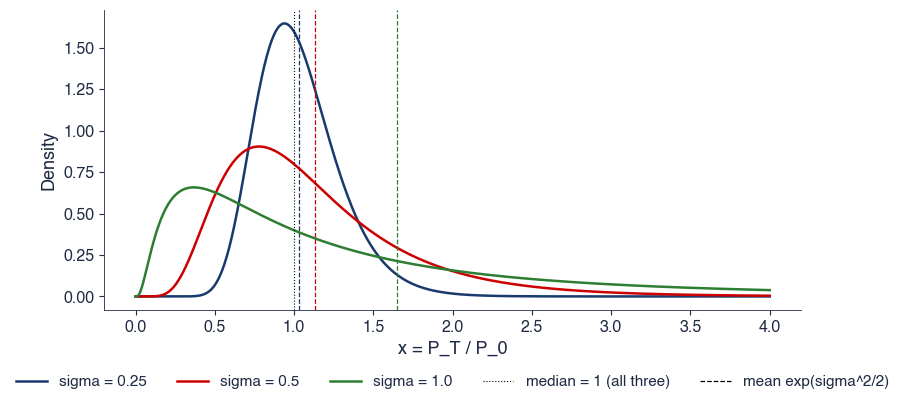

In [10]:
pd.DataFrame(fig_lognormal(save=False)).T

## 3. The central limit theorem

- Standardised means of Bernoulli(0.2) draws (port of SFEclt).
- Normal approximation of the binomial distribution (port of SFENormalApprox1-4).

In [11]:
def fig_clt(p=0.2, ns=(5, 30, 300), reps=20000, seed=7, save=True):
    """Central limit theorem: standardised means of n Bernoulli(p) draws against the standard Normal density."""
    rng = np.random.default_rng(seed)
    fig, axes = plt.subplots(1, len(ns), figsize=(10, 3.4), sharey=True)
    x = np.linspace(-4, 4, 400)
    out = {}
    for ax, n in zip(axes, ns):
        s = rng.binomial(n, p, size=reps)
        z = (s - n * p) / np.sqrt(n * p * (1 - p))
        vals, cnt = np.unique(z, return_counts=True)
        width = 1 / np.sqrt(n * p * (1 - p))
        ax.bar(vals, cnt / reps / width, width=width * 0.9, color=PAL['amber'], alpha=0.7,
               label='standardised mean of n draws' if n == ns[0] else '_')
        ax.plot(x, stats.norm.pdf(x), color=PAL['blue'], lw=1.8, label='N(0, 1) density' if n == ns[0] else '_')
        ax.set_title(f'n = {n}')
        ax.set_xlim(-4, 5)
        ax.set_xlabel('z')
        out[n] = {'skew_mean': (1 - 2 * p) / np.sqrt(n * p * (1 - p)), 'p_tail': float(np.mean(z > 1.96)),
                  'normal_tail': float(stats.norm.sf(1.96))}
    axes[0].set_ylabel('Density')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch2_clt')
    return out


def fig_normal_approx(cases=((5, 0.5), (20, 0.5), (20, 0.1), (100, 0.1)), save=True):
    """Normal approximation of the binomial distribution B(n, p) by N(np, np(1-p)), for four (n, p)."""
    fig, axes = plt.subplots(1, len(cases), figsize=(10.5, 3.3))
    out = {}
    for ax, (n, p) in zip(axes, cases):
        k = np.arange(0, n + 1)
        pmf = stats.binom.pmf(k, n, p)
        mu, sd = n * p, np.sqrt(n * p * (1 - p))
        lo, hi = max(0, int(mu - 4.5 * sd)), min(n, int(np.ceil(mu + 4.5 * sd)))
        ax.bar(k[lo:hi + 1], pmf[lo:hi + 1], color=PAL['amber'], alpha=0.7, width=0.85,
               label='binomial probabilities' if n == cases[0][0] and p == cases[0][1] else '_')
        x = np.linspace(lo - 0.5, hi + 0.5, 300)
        ax.plot(x, stats.norm.pdf(x, mu, sd), color=PAL['blue'], lw=1.8,
                label='Normal density N(np, np(1-p))' if n == cases[0][0] and p == cases[0][1] else '_')
        ax.set_title(f'n = {n}, p = {p}')
        ax.set_xlabel('k')
        # largest error of the cumulative probabilities (with continuity correction)
        err = np.max(np.abs(stats.binom.cdf(k, n, p) - stats.norm.cdf(k + 0.5, mu, sd)))
        out[f'{n}_{p}'] = {'n': n, 'p': p, 'max_cdf_err': float(err), 'np1p': n * p * (1 - p)}
    axes[0].set_ylabel('Probability')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch2_normal_approx')
    return out

{5: {'skew_mean': np.float64(0.6708203932499369),
  'p_tail': 0.0579,
  'normal_tail': 0.024997895148220435},
 30: {'skew_mean': np.float64(0.27386127875258304),
  'p_tail': 0.0266,
  'normal_tail': 0.024997895148220435},
 300: {'skew_mean': np.float64(0.08660254037844387),
  'p_tail': 0.028,
  'normal_tail': 0.024997895148220435}}

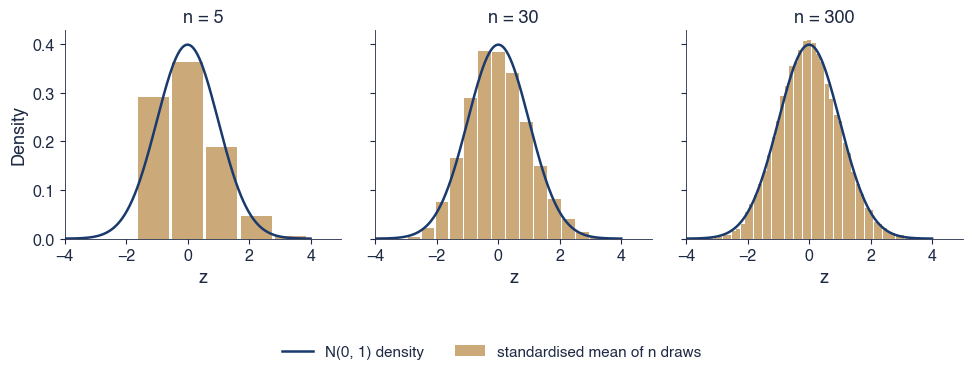

In [12]:
fig_clt(save=False)

{'5_0.5': {'n': 5,
  'p': 0.5,
  'max_cdf_err': 0.005569135060151331,
  'np1p': 1.25},
 '20_0.5': {'n': 20,
  'p': 0.5,
  'max_cdf_err': 0.0013909397882057029,
  'np1p': 5.0},
 '20_0.1': {'n': 20,
  'p': 0.1,
  'max_cdf_err': 0.03705294061805475,
  'np1p': 1.8},
 '100_0.1': {'n': 100,
  'p': 0.1,
  'max_cdf_err': 0.0174739980529085,
  'np1p': 9.0}}

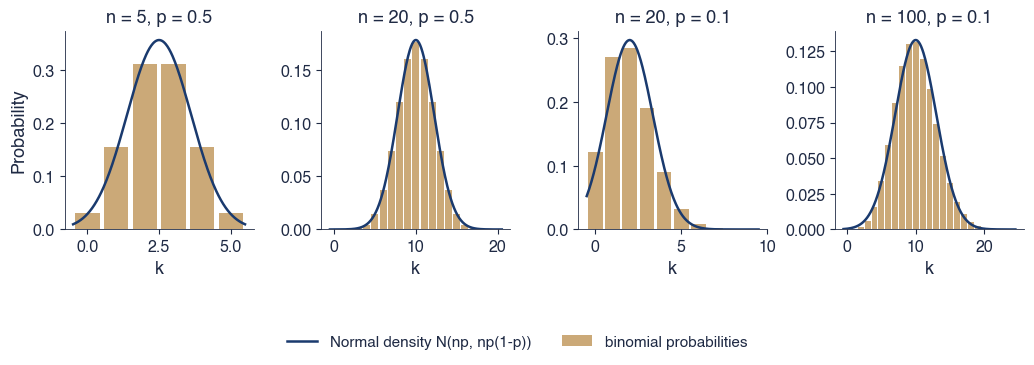

In [13]:
fig_normal_approx(save=False)

## 4. Moments, the Jarque-Bera test and a data check

- Moments of eight return series; the kernel density of DAX returns (port of SFEDaxReturnDistribution).
- Banca Transilvania, May 2016: two misplaced adjustment days and their effect on the kurtosis.

In [14]:
def moments_table(names=ASSETS, start=START):
    rows = {}
    for k in names:
        r = returns(k, start)
        rows[LABELS[k]] = {**moments(r), **t_fit(r), 'ppy': periods_per_year(r)}
    return pd.DataFrame(rows).T


def fig_shapes(save=True):
    """Same mean and variance, different shape: Normal vs Student-t(5) scaled to unit variance (kurtosis), and
    skew-Normal densities with negative and positive skewness."""
    x = np.linspace(-5, 5, 800)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    nu = 5
    c = np.sqrt((nu - 2) / nu)
    axes[0].plot(x, stats.norm.pdf(x), color=PAL['blue'], lw=1.8, label='Normal (excess kurtosis 0)')
    axes[0].plot(x, stats.t.pdf(x / c, nu) / c, color=PAL['red'], lw=1.8, label='Student-t(5), unit variance (excess kurtosis 6)')
    axes[0].set_title('Kurtosis: taller centre, heavier tails')
    out = {}
    for a, col, lab in [(-5, PAL['green'], 'negative skewness'), (5, PAL['purple'], 'positive skewness')]:
        m, v, s = stats.skewnorm.stats(a, moments='mvs')
        sd = np.sqrt(v)
        axes[1].plot(x, stats.skewnorm.pdf(x * sd + m, a) * sd, color=col, lw=1.8, label=f'{lab} ({float(s):+.2f})')
        out[lab] = float(s)
    axes[1].plot(x, stats.norm.pdf(x), color=PAL['blue'], lw=1.2, ls='--', label='_')
    axes[1].set_title('Skewness: a longer left or right tail')
    for ax in axes:
        ax.set_xlabel('Standardised value')
    axes[0].set_ylabel('Density')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.12, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch2_shapes')
    return out


def fig_dax_density(start=START, save=True):
    """DAX daily log returns: kernel density estimate against the Normal density with the same mean and standard
    deviation, on a linear and on a log scale (port of SFEDaxReturnDistribution)."""
    r = returns('dax', start)
    kde = stats.gaussian_kde(r)
    x = np.linspace(-9, 9, 700)
    fn = stats.norm.pdf(x, r.mean(), r.std())
    fk = kde(x)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
    for ax, log in zip(axes, [False, True]):
        ax.plot(x, fk, color=COLORS['dax'], lw=1.8, label='DAX, kernel density estimate')
        ax.plot(x, fn, color=PAL['red'], lw=1.5, ls='--', label='Normal, same mean and sd')
        ax.set_xlabel('Daily log return (%)')
        if log:
            ax.set_yscale('log')
            ax.set_ylim(1e-6, 1)
            ax.set_title('Log scale: the tails')
        else:
            ax.set_xlim(-5, 5)
            ax.set_title('Linear scale: the centre')
    axes[0].set_ylabel('Density')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch2_dax_density')
    z0 = 0.0
    return {'peak_kde': float(kde(r.mean())[0]), 'peak_normal': float(stats.norm.pdf(z0, 0, r.std())),
            'ratio_at6': float(kde(-6.0)[0] / stats.norm.pdf(-6.0, r.mean(), r.std())),
            'within1': float(np.mean(np.abs(r - r.mean()) <= r.std())), 'normal_within1': float(1 - 2 * stats.norm.sf(1))}


def tlv_check(start=START):
    """Banca Transilvania: the two largest reversals of the adjusted close (30-31 May 2016) and the excess kurtosis
    with and without them."""
    r = returns('tlv', start)
    t = read_market('TLV.RO').loc['2016-05-26':'2016-06-01']
    bad = ['2016-05-30', '2016-05-31']
    clean = r.drop(pd.to_datetime(bad))
    return {'r_bad': [float(r.loc[d]) for d in bad], 'close': {d.date().isoformat(): float(v) for d, v in t['close'].items()},
            'adj': {d.date().isoformat(): float(v) for d, v in t['adjusted_close'].items()},
            'exkurt': float(stats.kurtosis(r)), 'exkurt_clean': float(stats.kurtosis(clean)),
            'sd': float(r.std()), 'sd_clean': float(clean.std()), 'n': len(r),
            'nu': t_fit(r)['nu'], 'nu_clean': t_fit(clean)['nu']}

In [15]:
tab = moments_table()
tab[['n', 'mean', 'sd', 'skew', 'exkurt', 'se_kurt', 'jb', 'jb_p', 'min', 'min_date']].round(3)

,n,mean,sd,skew,exkurt,se_kurt,jb,jb_p,min,min_date
S&P 500,4201,0.045463,1.084485,-0.606031,13.490347,0.075584,32112.889547,0.0,-12.765218,2020-03-16
DAX,4244,0.033723,1.216337,-0.446913,7.432248,0.0752,9909.251855,0.0,-13.05486,2020-03-12
BET,4186,0.046124,1.070464,-0.97991,17.933083,0.075719,56761.527122,0.0,-11.892007,2018-12-19
Bitcoin,4384,0.118056,3.485192,-0.704892,11.95772,0.07399,26482.018755,0.0,-46.473021,2020-03-12
OMV Petrom,3815,0.075697,1.621951,-0.541053,8.919311,0.079316,12831.921347,0.0,-15.836832,2010-05-25
BRD,3771,0.044392,1.655393,-0.375145,7.260079,0.079777,8370.313855,0.0,-18.171837,2018-12-19
Nuclearelectrica,2911,0.098588,1.515928,0.271984,5.086307,0.0908,3173.768853,0.0,-9.421287,2020-03-09
Romgaz,2909,0.089676,1.399204,-0.342527,5.263579,0.090831,3414.991486,0.0,-11.034806,2026-08-31


{'negative skewness': -0.8509650126313717,
 'positive skewness': 0.8509650126313717}

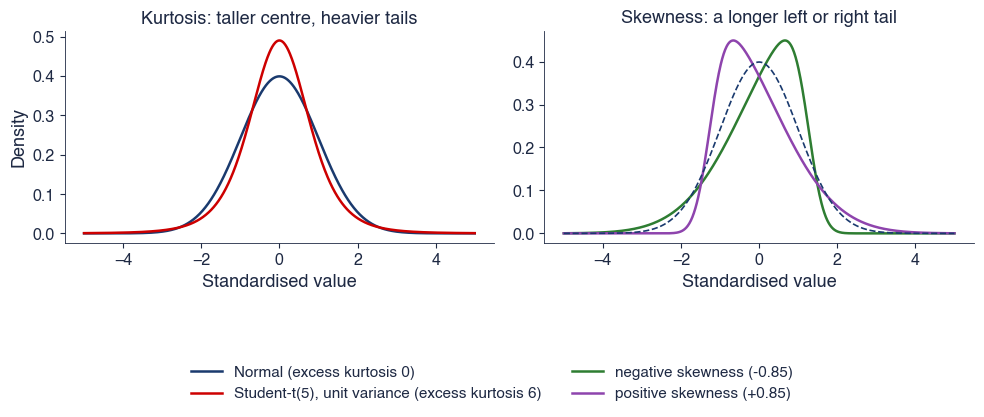

In [16]:
fig_shapes(save=False)

{'peak_kde': 0.4559802881501151,
 'peak_normal': 0.3279865976740803,
 'ratio_at6': 439.2049873331133,
 'within1': 0.7676720075400566,
 'normal_within1': 0.6826894921370859}

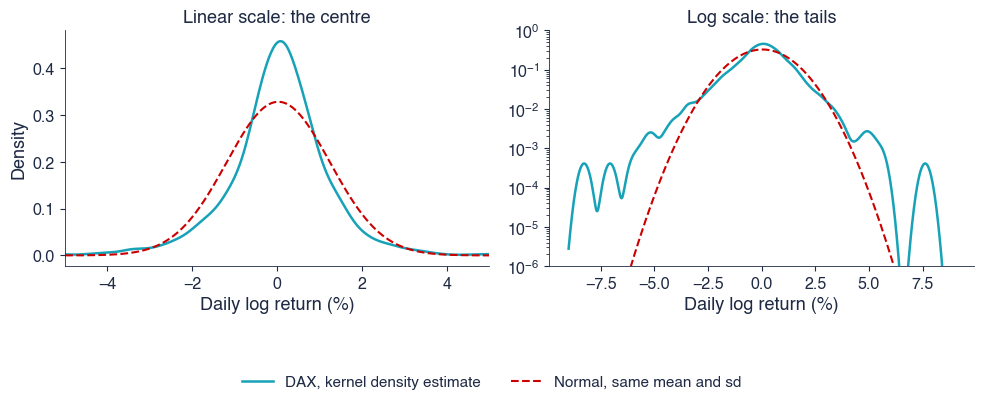

In [17]:
fig_dax_density(save=False)

In [18]:
tlv_check()

{'r_bad': [-15.008185059343093, 20.53379607141206],
 'close': {'2016-05-26': 2.8,
  '2016-05-27': 2.8251,
  '2016-05-30': 2.0898,
  '2016-05-31': 2.1299,
  '2016-06-01': 2.22},
 'adj': {'2016-05-26': 3.5695,
  '2016-05-27': 3.6014,
  '2016-05-30': 3.0995,
  '2016-05-31': 3.806,
  '2016-06-01': 3.9668},
 'exkurt': 17.482389699836407,
 'exkurt_clean': 13.51947372560188,
 'sd': 1.8053918879024098,
 'sd_clean': 1.7580046941739773,
 'n': 3790,
 'nu': np.float64(3.3346724004375172),
 'nu_clean': np.float64(3.4362693336983003)}

## 5. QQ plots and the Student-t distribution

- QQ plots against the Normal distribution and against the fitted Student-t.
- Student-t densities with unit variance; the fitted degrees of freedom and the AIC of both models.

In [19]:
def fig_qq(names=('sp500', 'bet', 'btc'), dist='norm', start=START, save=True):
    """QQ plots of daily log returns against the Normal distribution (standardised) or the fitted Student-t."""
    fig, axes = plt.subplots(1, len(names), figsize=(10.5, 3.6))
    out = {}
    for ax, k in zip(axes, names):
        r = returns(k, start)
        params = None
        if dist == 't':
            f = t_fit(r)
            params = (f['nu'], f['loc'], f['scale'])
        tq, eq = qq_points(r, dist, params)
        ax.scatter(tq, eq, s=6, color=COLORS[k], label=f'{SHORT[k]} daily log returns')
        lim = [min(tq.min(), eq.min()), max(tq.max(), eq.max())]
        ax.plot(lim, lim, color='black', lw=0.9, ls='--', label='45-degree line' if k == names[0] else '_')
        ax.set_title(SHORT[k] + (f' vs t({params[0]:.1f})' if dist == 't' else ' vs Normal'))
        ax.set_xlabel('Theoretical quantile' + (' (N(0,1))' if dist == 'norm' else ' (fitted t, %)'))
        out[k] = {'min_emp': float(eq.min()), 'min_theo': float(tq.min()), 'max_emp': float(eq.max()), 'max_theo': float(tq.max())}
    axes[0].set_ylabel('Empirical quantile' + (' (standardised)' if dist == 'norm' else ' (%)'))
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch2_qq_normal' if dist == 'norm' else 'sfm_ch2_qq_t')
    return out


def fig_t_densities(nus=(3, 5, 10), save=True):
    """Student-t densities scaled to unit variance against the standard Normal; linear and log scale."""
    x = np.linspace(-7, 7, 800)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
    cols = [PAL['red'], PAL['amber'], PAL['green']]
    out = {}
    for ax, log in zip(axes, [False, True]):
        ax.plot(x, stats.norm.pdf(x), color=PAL['blue'], lw=2, label='Normal')
        for nu, c in zip(nus, cols):
            s = np.sqrt((nu - 2) / nu)
            ax.plot(x, stats.t.pdf(x / s, nu) / s, color=c, lw=1.5, label=f't({nu}), unit variance')
        ax.set_xlabel('Standardised value')
        if log:
            ax.set_yscale('log')
            ax.set_ylim(1e-7, 1)
            ax.set_title('Log scale')
        else:
            ax.set_xlim(-4, 4)
            ax.set_title('Linear scale')
    axes[0].set_ylabel('Density')
    for nu in nus:
        s = np.sqrt((nu - 2) / nu)
        out[nu] = {'p4': float(2 * stats.t.sf(4 / s, nu)), 'exkurt': 6 / (nu - 4) if nu > 4 else np.inf}
    out['normal_p4'] = float(2 * stats.norm.sf(4))
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch2_t_densities')
    return out


def fig_t_fit(name='sp500', start=START, save=True):
    """Histogram of daily log returns with the fitted Normal and Student-t densities (linear and log scale)."""
    r = returns(name, start)
    f = t_fit(r)
    x = np.linspace(r.min() - 0.5, r.max() + 0.5, 800)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
    dens, edges = np.histogram(r, bins=120, density=True)
    mid = (edges[1:] + edges[:-1]) / 2
    for ax, log in zip(axes, [False, True]):
        if log:
            ax.scatter(mid[dens > 0], dens[dens > 0], s=12, color=COLORS[name], label='_')
        else:
            ax.hist(r, bins=160, density=True, color=COLORS[name], alpha=0.8, label=f'{SHORT[name]} (histogram)')
        ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), color=PAL['red'], lw=1.5, ls='--', label='Normal fit' if not log else '_')
        ax.plot(x, stats.t.pdf(x, f['nu'], f['loc'], f['scale']), color=PAL['green'], lw=1.8,
                label=f"Student-t fit, nu = {f['nu']:.2f}" if not log else '_')
        ax.set_xlabel('Daily log return (%)')
        if log:
            ax.set_yscale('log')
            ax.set_ylim(1e-5, 2)
            ax.set_title('Log scale (points: histogram heights)')
        else:
            ax.set_xlim(-5, 5)
            ax.set_title('Linear scale')
    axes[0].set_ylabel('Density')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig(f'sfm_ch2_t_fit_{name}')
    return f

{'sp500': {'min_emp': -11.814088149041973,
  'min_theo': -3.67479704115001,
  'max_emp': 8.340454737644775,
  'max_theo': 3.6747970411499566},
 'bet': {'min_emp': -11.153631850208454,
  'min_theo': -3.6738836525724405,
  'max_emp': 9.8271839267766,
  'max_theo': 3.6738836525723895},
 'btc': {'min_emp': -13.36981966828155,
  'min_theo': -3.685669520886434,
  'max_emp': 6.426157478863234,
  'max_theo': 3.6856695208864836}}

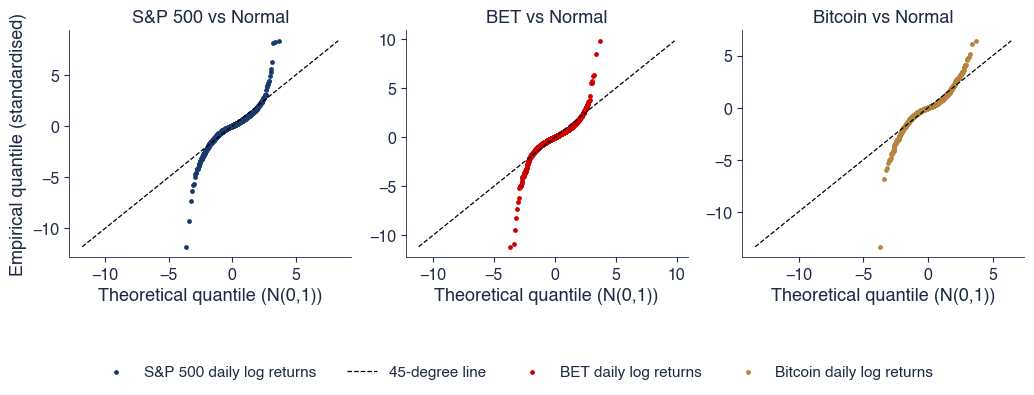

In [20]:
fig_qq(dist='norm', save=False)

{3: {'p4': 0.006165373138837158, 'exkurt': inf},
 5: {'p4': 0.003572826296160925, 'exkurt': 6.0},
 10: {'p4': 0.0011934668300203238, 'exkurt': 1.0},
 'normal_p4': 6.334248366623973e-05}

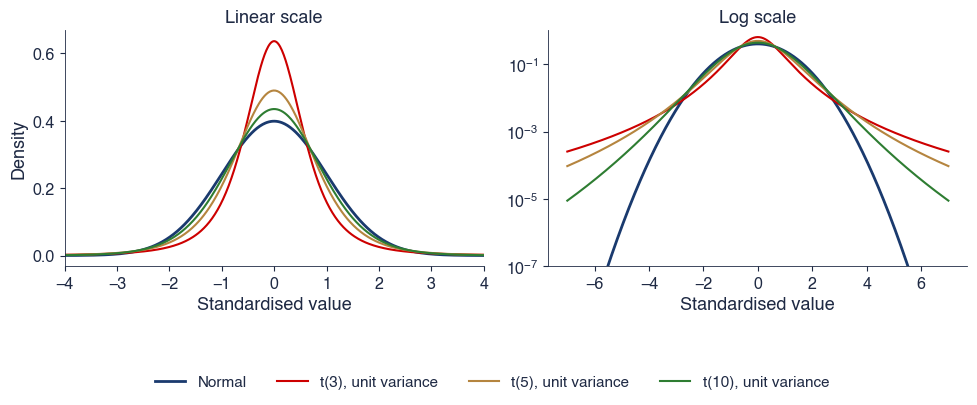

In [21]:
fig_t_densities(save=False)

In [22]:
tab[['nu', 'loc', 'scale', 'll_n', 'll_t', 'aic_n', 'aic_t']].round(2)

,nu,loc,scale,ll_n,ll_t,aic_n,aic_t
S&P 500,2.777175,0.086745,0.638995,-6301.185437,-5693.811651,12606.370875,11393.623301
DAX,3.305218,0.072698,0.808865,-6852.637008,-6481.929212,13709.274015,12969.858424
BET,2.964042,0.078117,0.628186,-6224.209423,-5496.408212,12452.418846,10998.816424
Bitcoin,2.229298,0.1341,1.845221,-11693.652159,-11025.20704,23391.304318,22056.414081
OMV Petrom,3.787857,0.080648,1.123198,-7257.798517,-6917.534584,14519.597034,13841.069168
BRD,4.672675,0.063632,1.241802,-7251.045099,-7011.06016,14506.090199,14028.120321
Nuclearelectrica,3.080486,0.059467,0.977896,-5341.087091,-5069.461703,10686.174182,10144.923405
Romgaz,3.40307,0.084141,0.943283,-5104.336254,-4862.277317,10212.672508,9730.554634


{'nu': np.float64(2.777174816283612),
 'loc': np.float64(0.08674518545262623),
 'scale': np.float64(0.6389954536039746),
 'll_t': np.float64(-5693.811650638048),
 'll_n': np.float64(-6301.185437299528),
 'aic_t': np.float64(11393.623301276097),
 'aic_n': np.float64(12606.370874599055),
 'sd_t': np.float64(1.2079251334782395)}

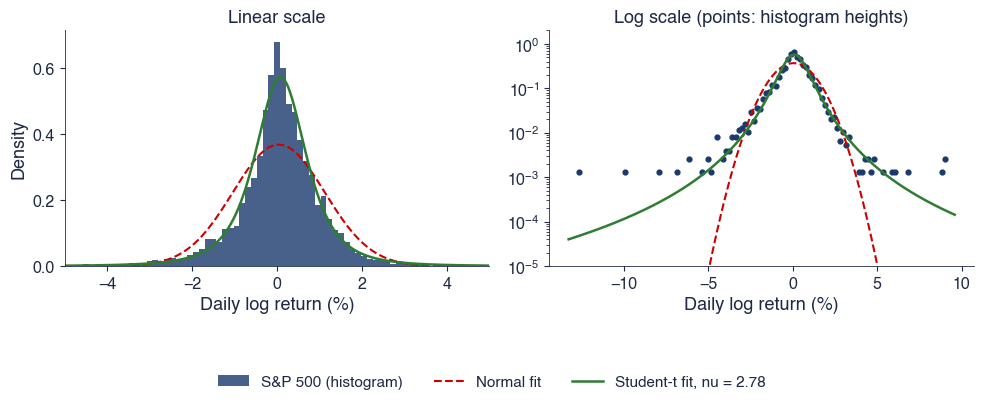

In [23]:
fig_t_fit(save=False)

{'sp500': {'min_emp': -12.76521830653392,
  'min_theo': -15.844147863992156,
  'max_emp': 9.089488332329232,
  'max_theo': 16.0176382348962},
 'bet': {'min_emp': -11.892007382004266,
  'min_theo': -13.411458203471264,
  'max_emp': 10.564511538205501,
  'max_theo': 13.567693039644311},
 'btc': {'min_emp': -46.47302066631713,
  'min_theo': -85.03646475264463,
  'max_emp': 22.51189543413279,
  'max_theo': 85.30466382864849}}

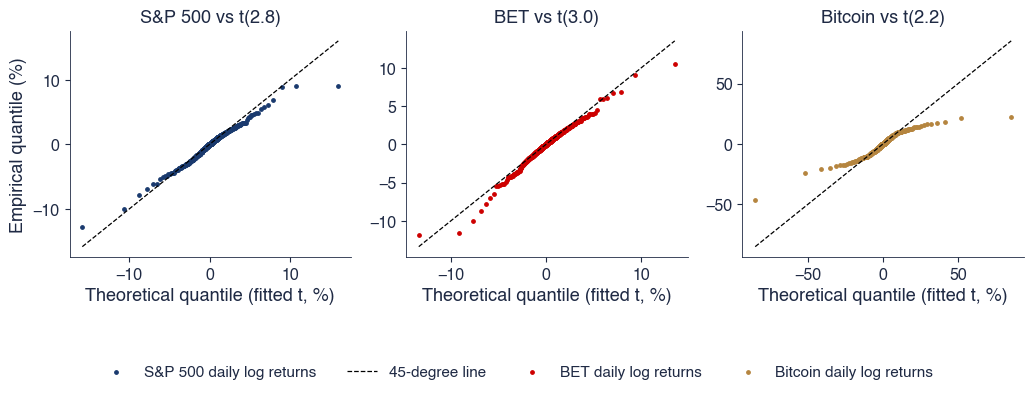

In [24]:
fig_qq(dist='t', save=False)

## 6. Stylised facts (Cont, 2001)

- Heavy tails: $k$-sigma days against the Normal expectation.
- Aggregational Gaussianity, absence of linear autocorrelation, volatility clustering, leverage effect, gain/loss asymmetry; a summary table.

In [25]:
def sigma_table(names=ASSETS, start=START, ks=(3, 4, 5, 6)):
    rows = {}
    for k in names:
        sd = sigma_days(returns(k, start), ks)
        rows[LABELS[k]] = {f'{c}{j}': sd[j][c] for j in ks for c in ('obs', 'exp', 'poisson_p', 'down', 'up')}
    return pd.DataFrame(rows).T


def fig_sigma_days(names=ASSETS, start=START, k=4, save=True):
    """Number of days beyond k standard deviations: observed vs expected under the Normal distribution."""
    fig, ax = plt.subplots(figsize=(10, 3.9))
    out = {}
    x = np.arange(len(names))
    obs, exp = [], []
    for k_ in names:
        sd = sigma_days(returns(k_, start), (3, 4, 5, 6))
        out[k_] = sd
        obs.append(sd[k]['obs'])
        exp.append(sd[k]['exp'])
    ax.bar(x - 0.2, obs, width=0.4, color=[COLORS[k_] for k_ in names], label=f'observed days beyond {k} sd')
    ax.bar(x + 0.2, exp, width=0.4, color=PAL['blue'], alpha=0.35, hatch='//', edgecolor=PAL['blue'],
           label=f'expected under the Normal distribution')
    for xi, o, e in zip(x, obs, exp):
        ax.text(xi - 0.2, o * 1.08, str(o), ha='center', va='bottom', fontsize=10, color='black')
        ax.text(xi + 0.2, e * 1.08, f'{e:.2f}', ha='center', va='bottom', fontsize=9, color=PAL['blue'])
    ax.set_yscale('log')
    ax.set_ylim(0.05, 80)
    ax.set_xticks(x)
    ax.set_xticklabels([SHORT[k_] for k_ in names])
    ax.set_ylabel('Number of days (log scale)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.13)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch2_sigma_days')
    return out


def fig_aggregation(names=INDICES, start=START, horizons=HORIZONS, save=True):
    """Aggregational Gaussianity: excess kurtosis of non-overlapping h-day log returns, h = 1, ..., 63."""
    fig, ax = plt.subplots(figsize=(9, 3.9))
    out = {}
    for k in names:
        r = returns(k, start)
        ku = [stats.kurtosis(aggregate(r, h)) for h in horizons]
        jbp = [stats.jarque_bera(aggregate(r, h)).pvalue for h in horizons]
        ax.plot(horizons, ku, marker='o', color=COLORS[k], lw=1.6, label=SHORT[k])
        out[k] = {h: {'exkurt': float(a), 'jb_p': float(b), 'n': len(aggregate(r, h))} for h, a, b in zip(horizons, ku, jbp)}
    ax.axhline(0, color='black', lw=0.8, ls='--', label='Normal distribution (0)')
    ax.set_xscale('log')
    ax.set_xticks(horizons)
    ax.set_xticklabels([str(h) for h in horizons])
    ax.set_xlabel('Horizon h (days, log scale)')
    ax.set_ylabel('Excess kurtosis of h-day returns')
    st.legend_outside_bottom(ax, ncol=5, y=-0.17)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch2_aggregation')
    return out


def fig_qq_horizons(name='sp500', start=START, save=True):
    """QQ plots of daily and monthly (21-day) log returns of one series against the Normal distribution."""
    r = returns(name, start)
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.7))
    out = {}
    for ax, h, lab in zip(axes, [1, 21], ['daily', 'monthly (21 days)']):
        x = aggregate(r, h)
        tq, eq = qq_points(x)
        ax.scatter(tq, eq, s=7, color=COLORS[name] if h == 1 else PAL['purple'], label=f'{SHORT[name]}, {lab}')
        lim = [min(tq.min(), eq.min()), max(tq.max(), eq.max())]
        ax.plot(lim, lim, color='black', lw=0.9, ls='--', label='45-degree line' if h == 1 else '_')
        ax.set_title(f'{lab}, n = {len(x)}')
        ax.set_xlabel('N(0,1) quantile')
        out[h] = {'n': len(x), 'exkurt': float(stats.kurtosis(x)), 'skew': float(stats.skew(x)), 'jb_p': float(stats.jarque_bera(x).pvalue)}
    axes[0].set_ylabel('Standardised empirical quantile')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch2_qq_horizons')
    return out


def fig_clustering(names=('sp500', 'bet', 'btc'), start=START, save=True):
    """Daily log returns over time: calm and turbulent periods alternate (volatility clustering)."""
    fig, axes = plt.subplots(len(names), 1, figsize=(10, 5.2), sharex=True)
    for ax, k in zip(axes, names):
        r = returns(k, start)
        ax.plot(r.index, r, color=COLORS[k], lw=0.5, label=f'{SHORT[k]} daily log return (%)')
        ax.set_ylabel('%')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch2_clustering')


def fig_acf(names=('sp500', 'bet', 'btc'), start=START, nlags=50, save=True):
    """Sample ACF of daily log returns (left) and of absolute returns (right), with the 95% band +-1.96/sqrt(n)."""
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), sharey=True)
    lags = np.arange(1, nlags + 1)
    out = {}
    nmin = 1e9
    for k in names:
        r = returns(k, start)
        nmin = min(nmin, len(r))
        a_r, a_a = acf(r, nlags), acf(r.abs(), nlags)
        axes[0].plot(lags, a_r, marker='o', ms=3, lw=0.8, color=COLORS[k], label=SHORT[k])
        axes[1].plot(lags, a_a, marker='o', ms=3, lw=0.8, color=COLORS[k], label='_')
        out[k] = {'n': len(r), 'rho_r': a_r[:10].tolist(), 'rho_abs': a_a.tolist(), 'band': 1.96 / np.sqrt(len(r)),
                  'lb_r': ljung_box(r.values, 10), 'lb_abs': ljung_box(r.abs().values, 10),
                  'n_out_r': int((np.abs(a_r) > 1.96 / np.sqrt(len(r))).sum()), 'max_abs_r': float(np.abs(a_r).max()),
                  'rho1_ex2020': float(acf(r.drop(r.loc['2020-02-20':'2020-04-30'].index), 1)[0])}
    b = 1.96 / np.sqrt(nmin)
    for ax in axes:
        ax.axhspan(-b, b, color=PAL['blue'], alpha=0.12, label='_')
        ax.axhline(0, color='black', lw=0.6)
        ax.set_xlabel('Lag (days)')
    axes[0].plot([], [], color=PAL['blue'], alpha=0.3, lw=6, label='95% band under independence')
    axes[0].set_title('Returns r_t')
    axes[1].set_title('Absolute returns |r_t|')
    axes[0].set_ylabel('Autocorrelation')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch2_acf')
    return out


def fig_leverage(names=INDICES, start=START, lags=20, save=True):
    """Leverage effect: L(k) = corr(r_t, |r_{t+k}|), k = 1..20 days."""
    fig, ax = plt.subplots(figsize=(9, 3.9))
    out = {}
    nmin = 1e9
    for k in names:
        r = returns(k, start)
        nmin = min(nmin, len(r))
        L = leverage(r, lags)
        ax.plot(np.arange(1, lags + 1), L, marker='o', ms=3.5, color=COLORS[k], lw=1.2, label=SHORT[k])
        out[k] = {'L': L.tolist(), 'mean5': float(L[:5].mean()), 'band': 1.96 / np.sqrt(len(r))}
    b = 1.96 / np.sqrt(nmin)
    ax.axhspan(-b, b, color=PAL['blue'], alpha=0.12)
    ax.plot([], [], color=PAL['blue'], alpha=0.3, lw=6, label='95% band under independence')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_xlabel('Lag k (days)')
    ax.set_ylabel('corr(r_t, |r_{t+k}|)')
    st.legend_outside_bottom(ax, ncol=5, y=-0.17)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch2_leverage')
    return out


def fig_gain_loss(names=ASSETS, start=START, save=True):
    """Gain/loss asymmetry: size of the 1% left tail quantile vs the 99% right tail quantile, and the number of
    days below -4 sd vs above +4 sd."""
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.7))
    x = np.arange(len(names))
    out = {}
    for i, k in enumerate(names):
        r = returns(k, start)
        m = moments(r)
        sd = sigma_days(r, (4,))[4]
        out[k] = {'q01': m['q01'], 'q99': m['q99'], 'skew': m['skew'], 'down4': sd['down'], 'up4': sd['up']}
    axes[0].bar(x - 0.2, [-out[k]['q01'] for k in names], width=0.4, color=PAL['red'], label='loss: -(1% quantile)')
    axes[0].bar(x + 0.2, [out[k]['q99'] for k in names], width=0.4, color=PAL['green'], label='gain: 99% quantile')
    axes[0].set_ylabel('% per day')
    axes[0].set_title('Size of a 1-in-100 day')
    axes[1].bar(x - 0.2, [out[k]['down4'] for k in names], width=0.4, color=PAL['red'], label='_')
    axes[1].bar(x + 0.2, [out[k]['up4'] for k in names], width=0.4, color=PAL['green'], label='_')
    axes[1].set_ylabel('Number of days')
    axes[1].set_title('Days below -4 sd and above +4 sd')
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels([SHORT[k] for k in names], rotation=45, ha='right')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch2_gain_loss')
    return out


def facts_table(names=ASSETS, start=START):
    """Cont (2001) stylised facts, one row per asset: the statistic behind each fact and whether it holds."""
    rows = {}
    for k in names:
        r = returns(k, start)
        n = len(r)
        m = moments(r)
        band = 1.96 / np.sqrt(n)
        rho_r = acf(r, 10)
        rho_a = acf(r.abs(), 10)
        lev = leverage(r, 5)
        month = aggregate(r, 21)
        rows[LABELS[k]] = {
            'exkurt': m['exkurt'], 'jb_p': m['jb_p'], 'heavy': bool(m['exkurt'] > 1 and m['jb_p'] < 0.05),
            'rho1': rho_r[0], 'n_sig_r': int((np.abs(rho_r) > band).sum()), 'band': band,
            'noacf': bool(np.mean(np.abs(rho_r)) < 0.05),
            'rho1_abs': rho_a[0], 'rho10_abs': rho_a[9], 'clust': bool(rho_a[9] > 3 * band),
            'lev1': lev[0], 'lev5': lev.mean(), 'lever': bool(lev.mean() < -band),
            'skew': m['skew'], 'q01': m['q01'], 'q99': m['q99'], 'gl_ratio': -m['q01'] / m['q99'],
            'gainloss': bool(m['skew'] < 0 and -m['q01'] > m['q99']),
            'exkurt_m': stats.kurtosis(month), 'agg': bool(stats.kurtosis(month) < m['exkurt'] / 2)}
    return pd.DataFrame(rows).T

In [26]:
sigma_table().round(3).T

,S&P 500,DAX,BET,Bitcoin,OMV Petrom,BRD,Nuclearelectrica,Romgaz
obs3,62.000,56.000,70.000,80.000,50.000,41.000,49.000,45.000
exp3,11.342,11.458,11.301,11.836,10.300,10.181,7.859,7.854
poisson_p3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
down3,41.000,35.000,47.000,48.000,29.000,25.000,25.000,27.000
up3,21.000,21.000,23.000,32.000,21.000,16.000,24.000,18.000
obs4,28.000,20.000,28.000,29.000,17.000,17.000,10.000,14.000
exp4,0.266,0.269,0.265,0.278,0.242,0.239,0.184,0.184
poisson_p4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
down4,16.000,12.000,20.000,18.000,10.000,9.000,5.000,10.000
up4,12.000,8.000,8.000,11.000,7.000,8.000,5.000,4.000


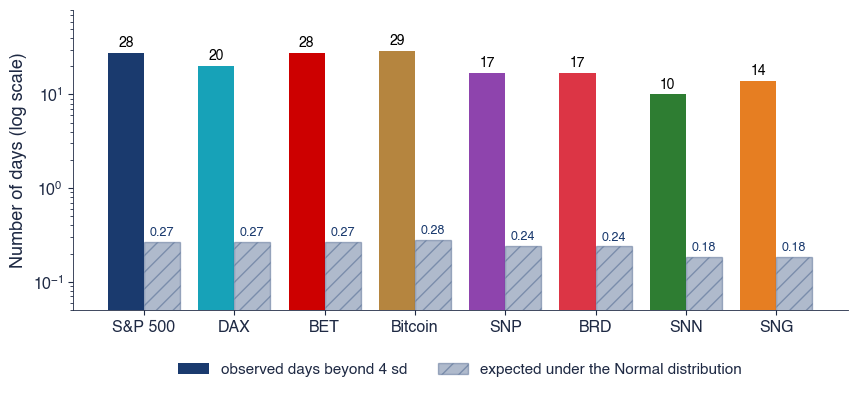

In [27]:
fig_sigma_days(save=False);

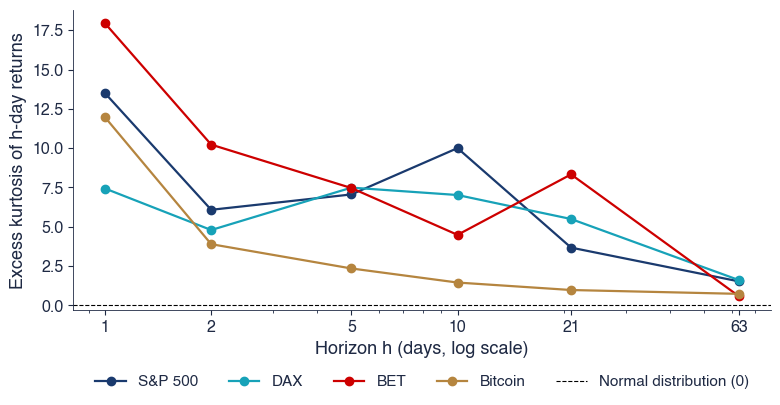

In [28]:
fig_aggregation(save=False);

{1: {'n': 4201,
  'exkurt': 13.490346561782669,
  'skew': -0.6060311505569804,
  'jb_p': 0.0},
 21: {'n': 200,
  'exkurt': 3.6750423927987397,
  'skew': -1.1812250448892618,
  'jb_p': 2.8888707734827255e-35}}

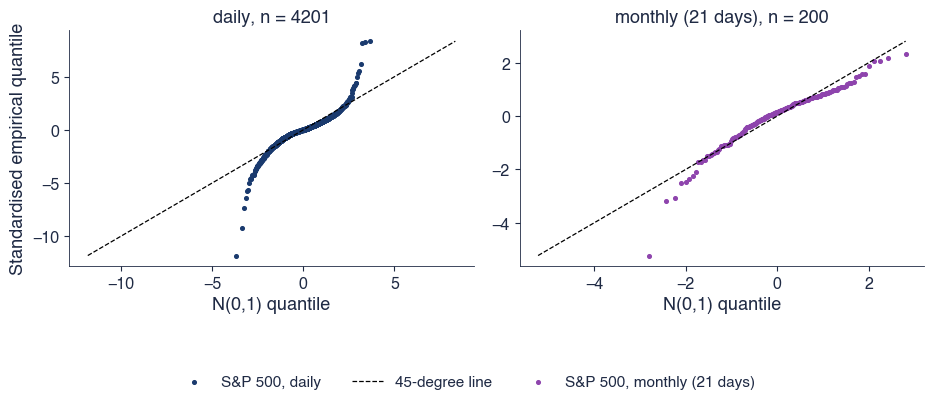

In [29]:
fig_qq_horizons(save=False)

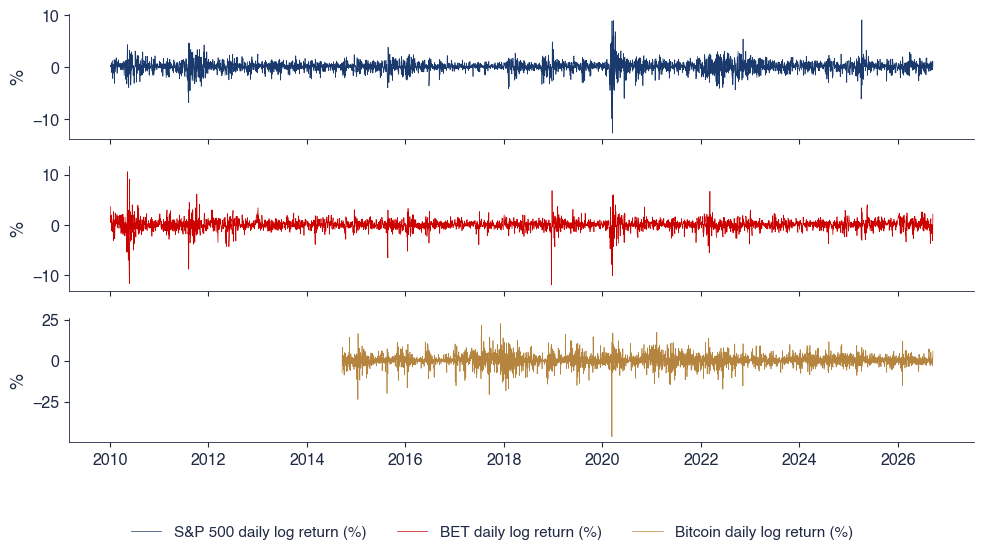

In [30]:
fig_clustering(save=False)

{'sp500': {'Q(10) returns': np.float64(198.9),
  'Q(10) |returns|': np.float64(3859.2)},
 'bet': {'Q(10) returns': np.float64(45.7),
  'Q(10) |returns|': np.float64(2120.1)},
 'btc': {'Q(10) returns': np.float64(20.2),
  'Q(10) |returns|': np.float64(1086.0)}}

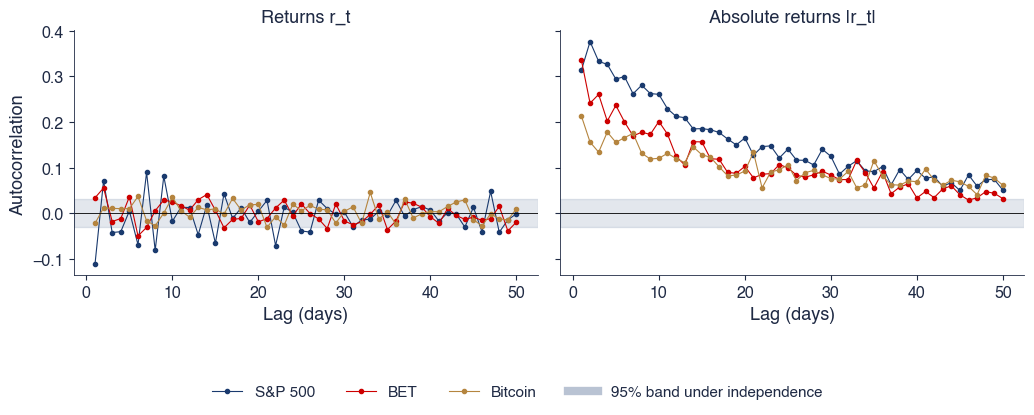

In [31]:
res = fig_acf(save=False)
{k: {'Q(10) returns': round(v['lb_r']['Q'], 1), 'Q(10) |returns|': round(v['lb_abs']['Q'], 1)} for k, v in res.items()}

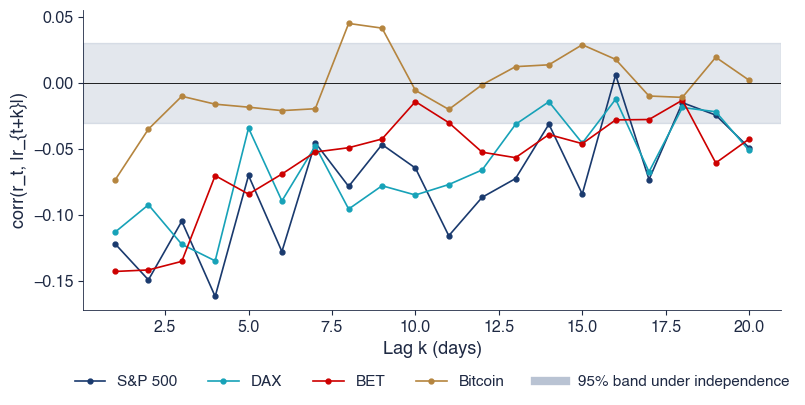

In [32]:
fig_leverage(save=False);

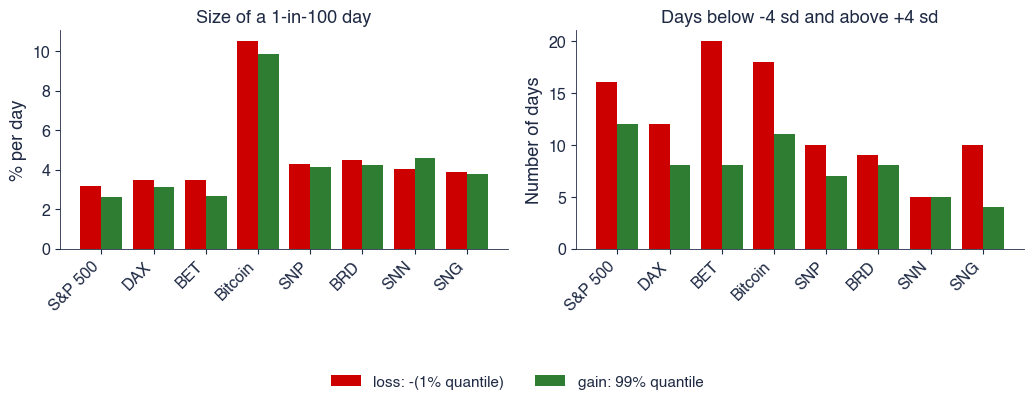

In [33]:
fig_gain_loss(save=False);

In [34]:
facts_table().round(3).T

,S&P 500,DAX,BET,Bitcoin,OMV Petrom,BRD,Nuclearelectrica,Romgaz
exkurt,13.490347,7.432248,17.933083,11.95772,8.919311,7.260079,5.086307,5.263579
jb_p,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
heavy,True,True,True,True,True,True,True,True
rho1,-0.111737,0.007752,0.033857,-0.022305,-0.015469,0.03183,0.093006,0.069661
n_sig_r,8,3,5,2,2,1,4,3
band,0.03024,0.030086,0.030294,0.029602,0.031733,0.031917,0.036327,0.03634
noacf,False,True,True,True,True,True,True,True
rho1_abs,0.313764,0.187942,0.335091,0.212652,0.233268,0.224777,0.306539,0.232377
rho10_abs,0.260516,0.159667,0.201083,0.120461,0.134948,0.105413,0.082667,0.08425
clust,True,True,True,True,True,True,False,False


## 7. AI for scientific discovery: are Bitcoin's tails getting thinner?

- Open question: does the tail of a crypto asset thin out as its market matures?
- Starter code: excess kurtosis and Student-t degrees of freedom by calendar year.
- Things to check before trusting any answer, yours or an AI's: the largest moves, the convergence of the optimiser, the noise of yearly estimates, calm vs turbulent years.

In [35]:
def fig_tails_by_year(names=('btc', 'sp500'), save=True):
    """Excess kurtosis and the fitted Student-t degrees of freedom of daily log returns, by calendar year."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
    out = {}
    for k in names:
        r = returns(k, '2015-01-01')
        g = r.groupby(r.index.year)
        yrs = [y for y, x in g if len(x) > 150]
        ku = [stats.kurtosis(g.get_group(y)) for y in yrs]
        nu = [t_fit(g.get_group(y))['nu'] for y in yrs]
        axes[0].plot(yrs, ku, marker='o', color=COLORS[k], lw=1.4, label=SHORT[k])
        axes[1].plot(yrs, np.minimum(nu, 30), marker='o', color=COLORS[k], lw=1.4, label='_')
        out[k] = {int(y): {'exkurt': float(a), 'nu': float(b)} for y, a, b in zip(yrs, ku, nu)}
    axes[0].set_title('Excess kurtosis by year')
    axes[1].set_title('Student-t degrees of freedom by year (capped at 30)')
    for ax in axes:
        ax.set_xlabel('Year')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch2_tails_by_year')
    return out

Spearman rank correlation of nu with the year: 0.63 (p = 0.03)


,btc,sp500
2015,2.04,5.360000e+00
2016,1.48,2.650000e+00
2017,2.81,3.030000e+00
2018,2.63,2.690000e+00
2019,2.06,3.590000e+00
2020,2.27,1.880000e+00
2021,5.06,7.370000e+00
2022,2.43,1.998000e+01
2023,2.22,2.616115e+10
2024,4.00,4.850000e+00


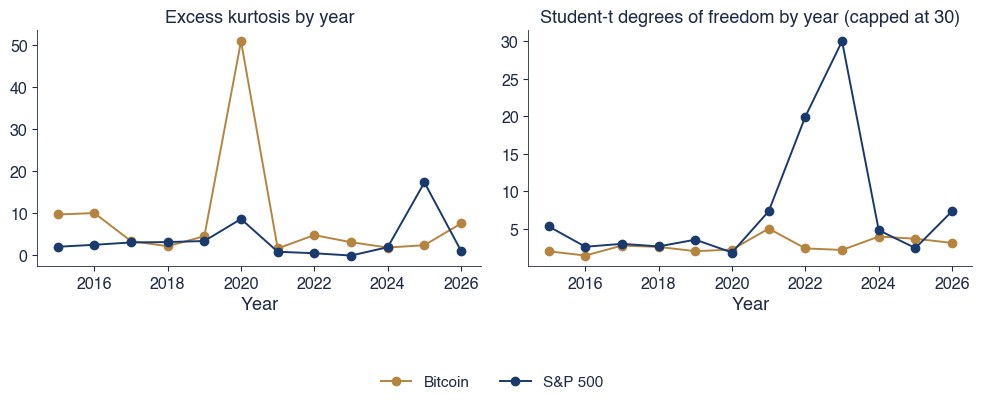

In [36]:
yrs = fig_tails_by_year(save=False)
nu = pd.Series({y: v['nu'] for y, v in yrs['btc'].items()})
print('Spearman rank correlation of nu with the year: %.2f (p = %.2f)' % stats.spearmanr(nu.index, nu.values))
pd.DataFrame({k: {y: v['nu'] for y, v in d.items()} for k, d in yrs.items()}).round(2)